Bollinger Bands Indikator

Bollinger Bands adalah indikator teknikal yang digunakan untuk mengukur volatilitas pasar dan mengidentifikasi kemungkinan area overbought atau oversold. Komponen bollinger bands.. 
1. Middle band
2. Upper band
3. Lower band

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
from matplotlib import pyplot as plt
import yfinance as yf

In [51]:
assets = ["TRX-USD"]
data = yf.download(assets, start="2024-05-01", end="2025-05-01")

[*********************100%***********************]  1 of 1 completed


In [52]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,TRX-USD,TRX-USD,TRX-USD,TRX-USD,TRX-USD
Date,,,,,
2024-05-01,0.120330,0.120920,0.117059,0.119467,482118834
2024-05-02,0.122292,0.123352,0.120104,0.120330,352230934
2024-05-03,0.122766,0.123922,0.121909,0.122292,275034834
2024-05-04,0.122322,0.123563,0.122321,0.122765,224837130
2024-05-05,0.121111,0.122349,0.120765,0.122322,196753191


In [53]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,TRX-USD,TRX-USD,TRX-USD,TRX-USD,TRX-USD
Date,,,,,
2025-04-26,0.251949,0.253115,0.241975,0.241983,685001974
2025-04-27,0.245487,0.254232,0.245411,0.251949,544084774
2025-04-28,0.248383,0.248383,0.243707,0.245479,557045277
2025-04-29,0.243890,0.249867,0.243270,0.248383,455299611
2025-04-30,0.246830,0.246997,0.242697,0.243882,480039646


In [54]:
def count_bollinger(dataawal, window = 20) :
    
    
    data = dataawal[['Close']].copy()

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel('Ticker')

    data['SMA-20'] = data['Close'].rolling(window).mean()
    data['STD'] = data['Close'].rolling(window).std()

    data['Upper']= data['SMA-20'] + (2.5 * data['STD'])
    data['Lower']= data['SMA-20'] - (2.5 * data['STD'])

    return data



In [55]:
trx_df = count_bollinger(data, 20)
trx_df.head()

Price,Close,SMA-20,STD,Upper,Lower
Date,,,,,
2024-05-01,0.120330,NaN,NaN,NaN,NaN
2024-05-02,0.122292,NaN,NaN,NaN,NaN
2024-05-03,0.122766,NaN,NaN,NaN,NaN
2024-05-04,0.122322,NaN,NaN,NaN,NaN
2024-05-05,0.121111,NaN,NaN,NaN,NaN


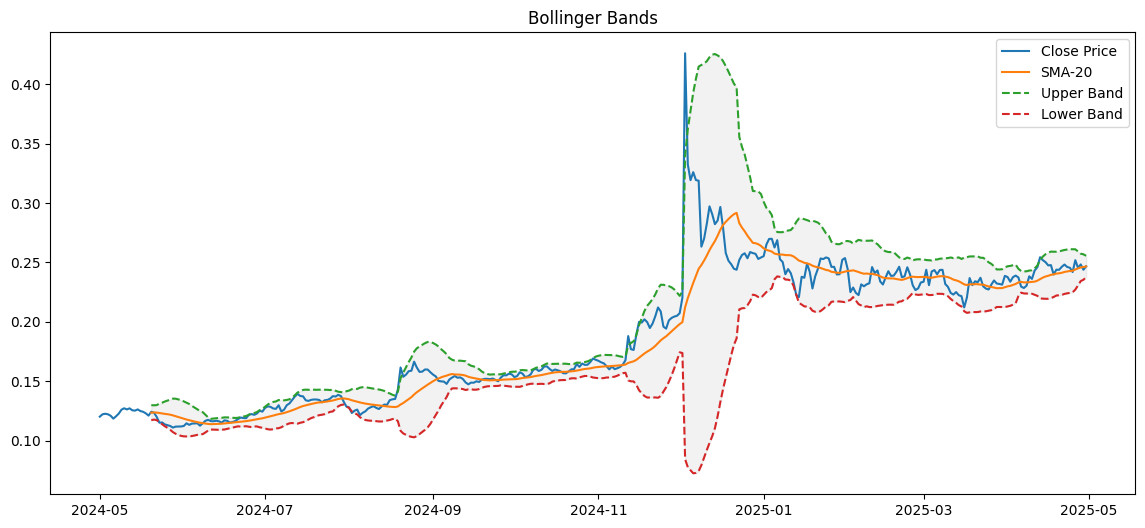

In [56]:
plt.figure(figsize=(14,6))
plt.plot(trx_df['Close'], label='Close Price')
plt.plot(trx_df['SMA-20'], label = 'SMA-20')
plt.plot(trx_df['Upper'], label = 'Upper Band', linestyle='--')
plt.plot(trx_df['Lower'], label = 'Lower Band', linestyle='--')
plt.fill_between(trx_df.index, trx_df['Lower'], trx_df['Upper'], color='gray', alpha=0.1)
plt.legend()
plt.title("Bollinger Bands")
plt.show()



In [57]:
def detect_flexible_signal(df):
    data = df.copy()
    data['SignalUp'] = False
    data['SignalLow'] = False
    above_upper = False
    under_lower = False

    for i in range(len(data)):
        close = data.iloc[i]['Close']
        upper = data.iloc[i]['Upper']
        lower = data.iloc[i]['Lower']

        if not above_upper and close > upper:
            above_upper = True
        elif above_upper and close < upper:
            above_upper = False

        if not under_lower and close < lower:
            under_lower = True
        elif under_lower and close > lower:
            under_lower   = False

        data.iloc[i, data.columns.get_loc('SignalUp')] = above_upper
        data.iloc[i, data.columns.get_loc('SignalLow')] = under_lower

    return data

In [58]:
trx_df2= detect_flexible_signal(trx_df)
trx_df2

Price,Close,SMA-20,STD,Upper,Lower,SignalUp,SignalLow
Date,,,,,,,
2024-05-01,0.120330,NaN,NaN,NaN,NaN,False,False
2024-05-02,0.122292,NaN,NaN,NaN,NaN,False,False
2024-05-03,0.122766,NaN,NaN,NaN,NaN,False,False
2024-05-04,0.122322,NaN,NaN,NaN,NaN,False,False
2024-05-05,0.121111,NaN,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...
2025-04-26,0.251949,0.244152,0.006785,0.261114,0.227190,False,False
2025-04-27,0.245487,0.245001,0.005701,0.259254,0.230747,False,False
2025-04-28,0.248383,0.245896,0.004602,0.257401,0.234390,False,False


In [59]:
print(f'Jumlah Signal Up : {(trx_df2["SignalUp"]== True).sum()}')
print(f'Jumlah Signal Down : {(trx_df2["SignalLow"]== True).sum()}')

Jumlah Signal Up : 7
Jumlah Signal Down : 4


In [60]:
def data_upper_lower(df):
    data = df.copy()

    data['Short-Signal'] = np.nan
    data['Short-Dot'] = 0
    data['Long-Signal'] = np.nan
    data['Long-Dot'] = 0

    above_upper = False  # tracking status    
    under_lower = False

    for i in range(len(data)):
        signalUp = data.iloc[i]['SignalUp']
        signallow = data.iloc[i]['SignalLow']
        close = data.iloc[i]['Close']

        if signalUp :
          data.iloc[i, data.columns.get_loc('Short-Signal')] = close           
          above_upper = True
        elif above_upper and not signalUp:
          #data.iloc[i, data.columns.get_loc('Short-Dot')] = 1
          if data['Close'].iloc[i] < data['Close'].iloc[i-1] < data['Close'].iloc[i-2]:
            data.iloc[i, data.columns.get_loc('Short-Dot')] = 1
            above_upper = False  

        if signallow :
          data.iloc[i, data.columns.get_loc('Long-Signal')] = close           
          under_lower = True
        elif under_lower and not signallow:
          #data.iloc[i, data.columns.get_loc('Short-Dot')] = 1
          if data['Close'].iloc[i] > data['Close'].iloc[i-1] > data['Close'].iloc[i-2]:
            data.iloc[i, data.columns.get_loc('Long-Dot')] = 1
            under_lower = False  
            
    return data

In [61]:
trx_df3= data_upper_lower(trx_df2)


In [62]:
trx_df3.head()

Price,Close,SMA-20,STD,Upper,Lower,SignalUp,SignalLow,Short-Signal,Short-Dot,Long-Signal,Long-Dot
Date,,,,,,,,,,,
2024-05-01,0.120330,NaN,NaN,NaN,NaN,False,False,NaN,0,NaN,0
2024-05-02,0.122292,NaN,NaN,NaN,NaN,False,False,NaN,0,NaN,0
2024-05-03,0.122766,NaN,NaN,NaN,NaN,False,False,NaN,0,NaN,0
2024-05-04,0.122322,NaN,NaN,NaN,NaN,False,False,NaN,0,NaN,0
2024-05-05,0.121111,NaN,NaN,NaN,NaN,False,False,NaN,0,NaN,0


In [63]:
print(f"Jumlah Titik Short : {trx_df3['Short-Dot'].sum()}")
print(f"Jumlah Titik Long : {trx_df3['Long-Dot'].sum()}")

Jumlah Titik Short : 5
Jumlah Titik Long : 3


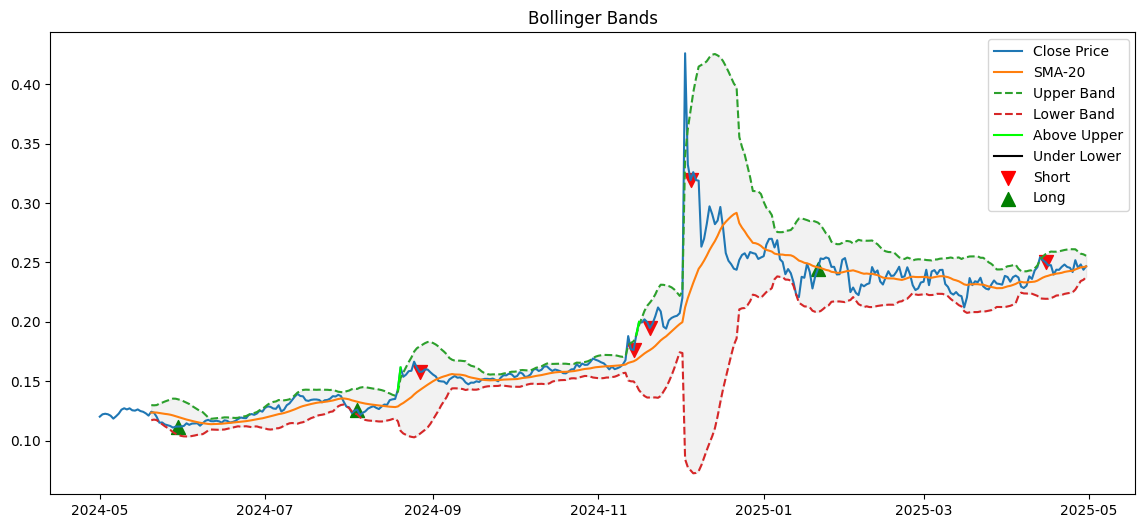

In [64]:
plt.figure(figsize=(14,6))
plt.plot(trx_df3['Close'], label='Close Price')
plt.plot(trx_df3['SMA-20'], label = 'SMA-20')
plt.plot(trx_df3['Upper'], label = 'Upper Band', linestyle='--')
plt.plot(trx_df3['Lower'], label = 'Lower Band', linestyle='--')
plt.plot(trx_df3['Short-Signal'], label = 'Above Upper', color='lime')
plt.plot(trx_df3['Long-Signal'], label = 'Under Lower', color='black')

plt.scatter(trx_df3.index[trx_df3['Short-Dot'] == 1], 
            trx_df3['Close'][trx_df3['Short-Dot'] == 1],
            marker='v', color='red', label='Short', s=100)

plt.scatter(trx_df3.index[trx_df3['Long-Dot'] == 1], 
            trx_df3['Close'][trx_df3['Long-Dot'] == 1],
            marker='^', color='green', label='Long', s=100)

plt.fill_between(trx_df3.index, trx_df3['Lower'], trx_df3['Upper'], color='gray', alpha=0.1)
plt.legend()
plt.title("Bollinger Bands")
plt.show()

Nah masih banyak false break yang terjadi terutama untuk skema short, kita akan kombinasikan dengan indikator lain

In [72]:
trx_df4 = trx_df3.copy()
trx_df4['Bandwidth'] = (trx_df4['Upper'] - trx_df4['Lower']) / trx_df4['SMA-20']

low_volatility_threshold = 0.05
trx_df4['LowVolatility'] = trx_df4['Bandwidth'] < low_volatility_threshold

def bandwidth_filter(df) :
    
    
    data = df.copy()
    '''
    data['filter-short'] = 0
    data['filter-long'] = 0

    for i in range(len(data)) :
        Shortdot = data.iloc[i]['Short-Dot']
        Longdot = data.iloc[i]['Long-Dot']
        low_volatility = data.iloc[i]['LowVolatility']
        
        if Shortdot == 1 and not low_volatility :
            data.iloc[i, data.columns.get_loc('filter-short')] = 1
        
        if Longdot == 1 and not low_volatility :
            data.iloc[i, data.columns.get_loc('filter-long')] = 1

    '''
    
    data['filter-short'] = ((data['Short-Dot'] == 1) & (~data['LowVolatility'])).astype(int)
    data['filter-long'] = ((data['Long-Dot'] == 1) & (~data['LowVolatility'])).astype(int)
    
    return data

In [73]:
trx_df5 = bandwidth_filter(trx_df4) 
print(f"Jumlah Titik Short : {trx_df5['filter-short'].sum()}")
print(f"Jumlah Titik Long : {trx_df5['filter-long'].sum()}")

Jumlah Titik Short : 5
Jumlah Titik Long : 3


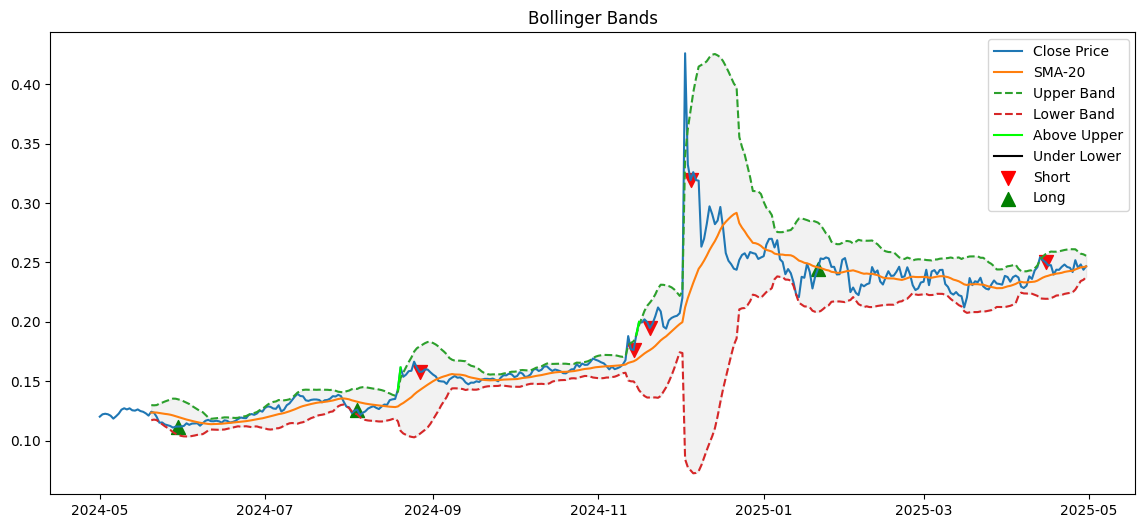

In [74]:
plt.figure(figsize=(14,6))
plt.plot(trx_df5['Close'], label='Close Price')
plt.plot(trx_df5['SMA-20'], label = 'SMA-20')
plt.plot(trx_df5['Upper'], label = 'Upper Band', linestyle='--')
plt.plot(trx_df5['Lower'], label = 'Lower Band', linestyle='--')
plt.plot(trx_df5['Short-Signal'], label = 'Above Upper', color='lime')
plt.plot(trx_df5['Long-Signal'], label = 'Under Lower', color='black')

plt.scatter(trx_df5.index[trx_df5['filter-short'] == 1], 
            trx_df5['Close'][trx_df5['filter-short'] == 1],
            marker='v', color='red', label='Short', s=100)

plt.scatter(trx_df5.index[trx_df5['filter-long'] == 1], 
            trx_df5['Close'][trx_df5['filter-long'] == 1],
            marker='^', color='green', label='Long', s=100)

plt.fill_between(trx_df5.index, trx_df5['Lower'], trx_df5['Upper'], color='gray', alpha=0.1)
plt.legend()
plt.title("Bollinger Bands")
plt.show()

bahkan setelah menggunakan filter bandwidth masih juga terapat false break.. kita akan gabungkan dengan indikator lain -- di proyek selanjutnya